# Non-autonomous 1D ODE

In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set_style("whitegrid")
from model import *
from torch.utils.data import DataLoader, Dataset
from scipy.integrate import odeint

torch.set_default_dtype(torch.float64)

## Read Data and Process Data

In [2]:
#Read data from .csv file
approx_sol = pd.read_csv('eg1_sol.csv', sep=',')
approx_solut = approx_sol.to_numpy()

#Data properties
components = 1 #spatial dimensions
deltat = 1/50 
t = np.arange(0.1, 2, deltat) #time steps of solution
time_steps = len(t)
n_initial_cond = approx_solut.shape[0] #number of initial conditions for solutions

#Read True RHS from .csv file
true_der = pd.read_csv('eg1_true_RHS.csv', sep=',')
true_der = true_der.to_numpy()

#Read Difference Quotients from .csv file
Diff_quot = pd.read_csv('eg1_app_RHS.csv', sep=',')
Diff_quot = Diff_quot.to_numpy()

Text(0, 0.5, 'x')

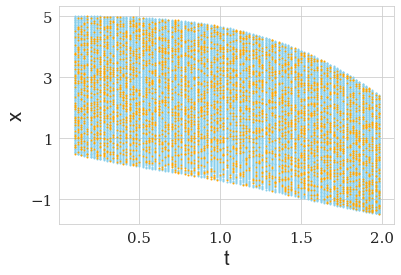

In [3]:
# Append t and x(t)
t_copy = np.tile(t, n_initial_cond).reshape(-1,1)
x_t = approx_solut.reshape(-1,1) 
inputs = np.append(t_copy, x_t, axis=1)
targets = Diff_quot.reshape(-1,1)

# train-test split 
X_train, X_test, Y_train, Y_test = train_test_split(inputs, targets, test_size=0.2)

# visualization
fontsize=15
plt.scatter(X_train[:,0], X_train[:,1], color='skyblue', s=1)
plt.scatter(X_test[:,0], X_test[:,1], color='orange', s=1)
plt.xticks([0.5,1,1.5,2], size = fontsize, fontname = 'serif')
plt.yticks([-1,1,3,5], size = fontsize, fontname = 'serif')
plt.xlabel('t', size=20)
plt.ylabel('x', size=20)
#plt.savefig('samples_non.pdf', bbox_inches = 'tight')

## Solution estimation

In [4]:
# Setup Parameters
N = 50
sigma = 1
reg_param = 0.00001

W = np.random.randn(2,N) / sigma
b = np.random.uniform(0, 2*np.pi, size=(N,))
A = np.cos(X_train @ W + b) * np.sqrt(2/N)
c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train)

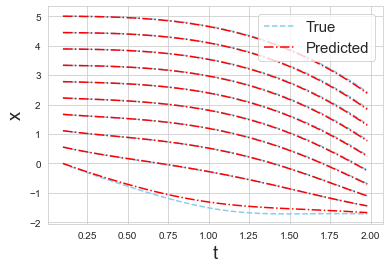

In [5]:
def g(x,t):
    A = np.cos(W[0] * t + W[1] * x + b)
    return np.sum(A * c.reshape(-1) * np.sqrt(2/N))

def fun(x, t):
    return np.exp(-x) * np.log(t) - t**2

# time stamps
deltat = 1/50 
tStop =  2
t = np.arange(0.1, tStop, deltat)

# 200 initial conditions
x_0 = np.linspace(0,5,10)

for i in x_0:

    # solve
    sol = odeint(fun, i, t)
    sol_app = odeint(g, i, t)

    # transpose the solution, each row is a trajectory
    data = sol.T
    data1 = sol_app.T
    
    plt.plot(t, data.reshape(-1), '--', c='skyblue')
    plt.plot(t, data1.reshape(-1), '-.', c='red')

plt.legend(['True', 'Predicted'], fontsize=15 )
#plt.xticks(size=15)
#plt.yticks(size=15)
plt.xlabel('t', size=18)
plt.ylabel('x', size=18)
plt.savefig('Eg1_RF_sol.pdf', bbox_inches = 'tight')

## Define Random Features

In [13]:
n = 100 #grid points where we do the recovery

# Define real RHS
def z_func(t,x):
    return np.log(t) * np.exp(-x) - t ** 2

#define recovery domain boundaries
x_low = 0
x_top = 5
t_low = 0.1
t_top = 2.

#generate grid of x and t in the recovery domain
x = np.linspace(x_low, x_top, n)
time1 = np.linspace(t_low, t_top, n)
T,X = np.meshgrid(time1,x)

#compute true RHS on grid
Z = z_func(T, X)

#Generate input for netowrk
new_X = X.reshape(-1,1)
new_T = T.reshape(-1,1)
X_new = np.append(new_T,new_X,axis = 1)

In [15]:
# Setup Parameters
N_range = range(10,201,10)      # number of features
sigma_range = np.linspace(0.2,4,20)  # variance parameter
T = 10                          # repeat T times
reg_param = 0.0001                # fixed regularization parameter

# record errors
train_errors = np.zeros((T, len(N_range), len(sigma_range)))
test_errors = np.zeros((T, len(N_range), len(sigma_range)))
non_rel_errors = np.zeros((T, len(N_range), len(sigma_range)))
Lip_cons = np.zeros((T, len(N_range), len(sigma_range)))

for t in range(T):
    
    for i in range(len(N_range)):
        
        N = N_range[i]
        
        for j in range(len(sigma_range)):
            
            sigma = sigma_range[j]
            W = np.random.randn(2,N) / sigma
            b = np.random.uniform(0, 2*np.pi, size=(N,))
            A = np.cos(X_train @ W + b) * np.sqrt(2/N)
            c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train)
            
            Lip_cons[t,i,j] = np.sum( np.abs(c.reshape(-1)) * np.linalg.norm(W,axis=0) )

            # training loss
            train_errors[t,i,j] = np.mean((A @ c - Y_train)**2)

            # test loss
            A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
            test_errors[t,i,j] = np.mean((A_test @ c - Y_test)**2)

            # non-trajectory data relative errors
            A_non = np.cos(X_new @ W + b) * np.sqrt(2/N)
            Z_RF = A_non @ c
            Z_RF = Z_RF.reshape(n,n)
            non_rel_errors[t,i,j] = np.mean(abs(Z - Z_RF))/(np.abs(np.max(Z)-np.min(Z)))

In [17]:
np.savez_compressed('errors.npz', train=train_errors, test=test_errors, rel=non_rel_errors)

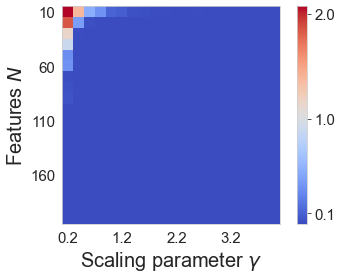

In [58]:
im = plt.imshow(np.mean(test_errors, axis=0), cmap='coolwarm')
plt.grid(visible=False)
cb = plt.colorbar(im,ticks=[0.1,1,2])
cb.ax.tick_params(labelsize=15)
plt.xticks([0,5,10,15],[0.2,1.2,2.2,3.2], size=15)
plt.yticks([0,5,10,15],[10, 60, 110, 160], size=15)
plt.xlabel(r'Scaling parameter $\gamma$', size=20)
plt.ylabel(r'Features $N$', size=20)
plt.savefig('Para_test.pdf', bbox_inches = 'tight')

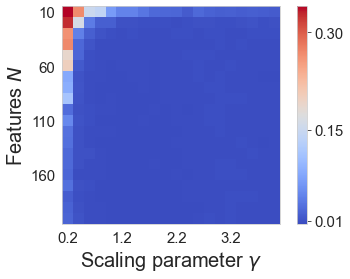

In [66]:
im = plt.imshow(np.mean(non_rel_errors, axis=0), cmap='coolwarm')
plt.grid(visible=False)
cb = plt.colorbar(im,ticks=[0.01,0.15,0.3])
cb.ax.tick_params(labelsize=15)
plt.xticks([0,5,10,15],[0.2,1.2,2.2,3.2], size=15)
plt.yticks([0,5,10,15],[10, 60, 110, 160], size=15)
plt.xlabel(r'Scaling parameter $\gamma$', size=20)
plt.ylabel(r'Features $N$', size=20)
plt.savefig('Para_rel.pdf', bbox_inches = 'tight')

Scaling parameter is 1.0
Slope is  -2.1450028284015987


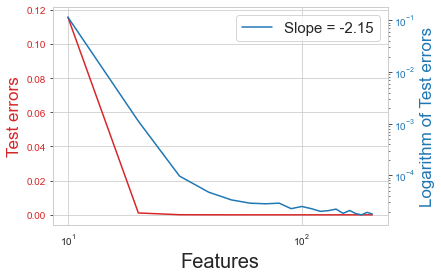

In [163]:
# Visualization: Line plot

# read data
data = np.load('errors.npz')
test_errors = data['test']
non_rel_errors = data['rel']

# line plot for a fixed N
fig, ax1 = plt.subplots()

idx = 4
print('Scaling parameter is', sigma_range[idx])

color = 'tab:red'
ax1.set_xlabel('Features', size=20)
ax1.set_ylabel('Test errors', color=color, size=17)
ax1.plot(N_range, np.mean(test_errors,axis=0)[:,idx], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

k = np.polyfit(np.log(N_range), np.log(np.mean(test_errors,axis=0)[:,idx]), deg=1)[0]
print('Slope is ', k)

color = 'tab:blue'
ax2.set_ylabel('Logarithm of Test errors', color=color, size=17)  # we already handled the x-label with ax1
ax2.loglog(N_range, np.mean(test_errors,axis=0)[:,idx], color=color, label=f'Slope = {k:.2f}')
ax2.legend(fontsize=15)
ax2.tick_params(axis='y', labelcolor=color)

plt.grid(visible=False)
plt.savefig('Para_N.pdf', bbox_inches = 'tight')

# Lipschitz Constant

In [73]:

# Setup Parameters
N_range = range(10,201,10)      # number of features
sigma_range = np.linspace(0.2,4,20)  # variance parameter
T = 5                         # repeat T times
reg_param = 0.0001                # fixed regularization parameter

# record errors
train_errors = np.zeros((T, len(N_range), len(sigma_range)))
test_errors = np.zeros((T, len(N_range), len(sigma_range)))
non_rel_errors = np.zeros((T, len(N_range), len(sigma_range)))

Lip_cons = np.zeros((T, len(N_range), len(sigma_range)))

for t in range(T):
    
    for i in range(len(N_range)):
        
        N = N_range[i]
        
        for j in range(len(sigma_range)):
            
            sigma = sigma_range[j]
            W = np.random.randn(2,N) / sigma
            b = np.random.uniform(0, 2*np.pi, size=(N,))
            A = np.cos(X_train @ W + b) * np.sqrt(2/N)
            c = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train)
            
            Lip_cons[t,i,j] = np.sum( np.abs(c.reshape(-1)) * np.linalg.norm(W,axis=0) )

            # training loss
            train_errors[t,i,j] = np.mean((A @ c - Y_train)**2)

            # test loss
            A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
            test_errors[t,i,j] = np.mean((A_test @ c - Y_test)**2)

            # non-trajectory data relative errors
            A_non = np.cos(X_new @ W + b) * np.sqrt(2/N)
            Z_RF = A_non @ c
            Z_RF = Z_RF.reshape(n,n)
            non_rel_errors[t,i,j] = np.mean(abs(Z - Z_RF))/(np.abs(np.max(Z)-np.min(Z)))

In [74]:
pd.DataFrame(np.mean(Lip_cons, axis=0))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,8.950292,29.686413,19.531510,36.807359,59.315371,32.243908,67.529370,77.225101,77.574919,115.122068,86.809829,148.931549,275.307342,102.643392,152.523589,160.847162,183.769047,367.315018,113.436430,327.081445
1,43.642703,120.676052,63.726161,105.441659,171.616674,184.968310,252.047101,206.878955,246.354189,254.078118,309.768253,218.743696,332.583817,322.631870,270.807873,335.545165,338.642998,350.955488,310.634922,335.610398
2,80.772777,238.399238,296.897325,185.783135,172.343605,250.008574,233.210575,252.760416,284.786406,287.297159,278.076282,306.664018,311.564640,354.262609,283.081032,342.183914,364.607259,326.057869,390.847395,376.963220
3,153.724286,415.362088,196.000167,233.973261,228.598960,250.692200,257.559401,268.975534,272.415190,266.327241,331.370480,358.384299,322.366170,324.535828,347.719361,352.680062,395.180773,409.442198,354.723840,433.549865
4,207.408757,272.538529,252.071859,196.909035,262.314586,216.831338,303.753045,274.749801,307.487269,381.584654,341.988170,375.975076,347.085709,344.553504,357.850269,398.128691,434.762144,470.847453,462.630019,442.664980
5,428.066698,206.062158,192.368837,252.896847,228.417689,287.941965,339.259862,340.445049,332.994758,350.579955,383.907643,384.117629,445.358056,384.795972,427.625346,394.954073,423.711474,442.171114,488.477890,478.497407
6,558.664030,186.048358,245.398343,233.069758,264.772581,280.039147,324.114110,354.479900,337.124579,385.812036,414.464332,466.536355,456.615539,391.961260,457.546054,464.947286,470.630207,463.539650,483.073211,487.397581
7,956.556190,224.651313,255.420728,281.802181,289.062895,320.819626,306.149621,342.757492,374.750123,387.708874,401.646514,420.478378,474.861319,499.081026,488.520455,485.665206,538.731786,514.439708,461.773843,443.351244
8,1341.606360,250.597373,264.578913,252.146962,294.434079,352.312440,336.211815,355.100346,372.435072,422.335625,455.886514,442.081834,466.435985,464.208324,477.987878,487.135873,555.219189,540.168139,474.868151,610.656325
9,854.804896,270.854698,251.352298,301.171476,339.194282,347.659366,352.933575,404.385499,399.143119,421.459609,462.610144,448.506995,462.069934,477.925399,488.314483,511.725708,582.529526,550.347312,589.388515,605.710909


plt.figure(figsize=(20,20))
heatmap = sns.heatmap( np.mean(test_errors, axis=0), annot=True, 
            linewidth=.5, fmt=".1e", cmap='summer', 
            annot_kws={"size":10}, 
            xticklabels=sigma_range, yticklabels=N_range)


# Get the colorbar object
cbar = heatmap.collections[0].colorbar

# Adjust the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=20)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel(r'Scaling Parameter $\gamma$ ', fontsize=40)
plt.ylabel(r'Number of Random Features $N$', fontsize=40)
plt.savefig('test_error.pdf', bbox_inches = 'tight')
#a = np.min(np.mean(non_rel_errors, axis=0))
#print('Best error is {:.2e}'.format(a))

plt.figure(figsize=(20,20))
heatmap = sns.heatmap( np.mean(non_rel_errors, axis=0), annot=True, 
            linewidth=.5, fmt=".1e", cmap='summer', 
            annot_kws={"size":10}, 
            xticklabels=sigma_range, yticklabels=N_range)


# Get the colorbar object
cbar = heatmap.collections[0].colorbar

# Adjust the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=20)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel(r'Scaling Parameter $\gamma$ ', fontsize=40)
plt.ylabel(r'Number of Random Features $N$', fontsize=40)
#plt.savefig('test_error.pdf', bbox_inches = 'tight')
#a = np.min(np.mean(non_rel_errors, axis=0))
#print('Best error is {:.2e}'.format(a))